#  Adiabatic state preparation



## Introduction

In adiabatic quantum computing, the system in initialized in the easy to prepare ground state of a Hamiltonian $H_0$, and then the Hamiltonian is gradually transformed into $H_1$, which is constructed in such a way that the groundstate of $H_1$ encodes the solution to a difficult problem. The transformation of $H_0$ to $H_1$ can be written in the form

$\displaystyle H(t) = (1-\lambda(t)) H_0 + \lambda(t) H_1$

where $\lambda(t)$ is a function that goes from goes from $0$ to $1$ when $t$ goes from $0$ to $t_{\rm final}$.

If this gradual tranformation is slow enough (satisfying the adiabicity critera), the evolution of the system will remain in its ground state.

If the Hamiltonian is transformed from $H_0$ to $H_1$ too quickly, the system will get excited from the ground state and the adiabatic computing algorithm fails.

In this notebook we explore the dynamics under a spin Hamiltonian that is transformed from a simple Hamiltonian with an easy to prepare ground state, into an Ising Hamiltonian with an antiferromagnetic ground state.

## Setting up the system

Consider the Hamiltonians
$$
H_0 = -\sum_{i=1}^N \sigma^x_i
$$
and
$$
H_1 = \frac{1}{2}\sum_{i=1}^{N-1} J_z \sigma^z_i\sigma^z_{i+1} - \frac{1}{2}\sum_{i=1}^{N} h \sigma^z_i
$$
with $J_z=2\pi$ and $h=0.5\cdot 2\pi$.

Build the matrix representation of $H_0$ and $H_1$ and the initial state vector $|\psi(0)\rangle=\left[(|0\rangle+|1\rangle)/\sqrt{2}\right]^{\otimes N}$. Use a small $N$ to check the correctness of your code manually. As a first step, you may want to use the function buildSparseGateSingle(n, i, gate) from exercise sheet 2 to build the matrix representations of single qubit Pauli operators acting on an $N$-qubit system.


In [1]:
import numpy as np
from scipy.sparse import kron, identity, csc_matrix

# Pauli matrices as sparse matrices
I = csc_matrix(np.array([[1, 0], [0, 1]], dtype=complex))
X = csc_matrix(np.array([[0, 1], [1, 0]], dtype=complex))
Y = csc_matrix(np.array([[0, -1j], [1j, 0]], dtype=complex))
Z = csc_matrix(np.array([[1, 0], [0, -1]], dtype=complex))

def buildSparseGateSingle(N, i, gate):
    """
    Build the sparse matrix of a single-qubit gate acting on qubit i in an N-qubit system.
    Qubits are indexed from 0 to N-1 (leftmost qubit is 0).
    """
    op = 1
    for j in range(N):
        if j == i:
            op = kron(op, gate, format='csc')
        else:
            op = kron(op, I, format='csc')
    return op

def H0_transverse(N):
    """H0 = - sum_i sigma^x_i"""
    H0 = csc_matrix((2**N, 2**N), dtype=complex)
    for i in range(N):
        H0 -= buildSparseGateSingle(N, i, X)
    return H0

def H1_ising(N, Jz=2*np.pi, h=0.5*2*np.pi):
    """
    H1 = 0.5 * sum_{i} Jz sigma^z_i sigma^z_{i+1} - 0.5 * sum_i h sigma^z_i
    """
    H1 = csc_matrix((2**N, 2**N), dtype=complex)
    for i in range(N-1):
        H1 += 0.5 * Jz * buildSparseGateSingle(N, i, Z) @ buildSparseGateSingle(N, i+1, Z)
    for i in range(N):
        H1 -= 0.5 * h * buildSparseGateSingle(N, i, Z)
    return H1

def initial_state(N):
    psi_single = np.array([1, 1], dtype=complex)/np.sqrt(2)
    psi0 = psi_single
    for _ in range(N-1):
        psi0 = np.kron(psi0, psi_single)
    return psi0

N = 3  # small N for manual checking
H0 = H0_transverse(N)
H1 = H1_ising(N)
psi0 = initial_state(N)

print("H0 shape:", H0.shape)
print("H1 shape:", H1.shape)
print("Initial state vector:", psi0)

H0 shape: (8, 8)
H1 shape: (8, 8)
Initial state vector: [0.35355339+0.j 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j
 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j]


## Exercise 2: Instantaneous eigenstates

Using $N=5$ and $\lambda(t)=t/t_{\rm final}$ with $t_{\rm final}=50$, calculate the eigenvalues and eigenstates of $H(t)$ for a grid of 100 points between $t=0$ and $t_{\rm final}$ and plot the lowest 20 eigenenergies as a function of time.

Also calculate the overlap of instantaneous ground state with the initial state and with the ground state of $H_1$ as a function of time. You should see how the character of the state changes gradually from one to the other. At the point where the excitation gap is smallest this change should be the fastest.

## Time evolution

Simulate the time evolution under $H(t)$ using the parameters given above. You can use the qutip function mesolve(), which allows you to solve the time-dependent Schrödinger equation, see https://qutip.org/docs/3.0.1/guide/dynamics/dynamics-time.html, or alternatively a scipy solver for ordinary differential equations.

Calculate the overlap of the obtained $|\psi(t)\rangle$ with the instantaneous eigenstates and plot them as a function of time. Try this for different values of $t_{\rm final}$ and interpret your results.

Compare your results for an odd number of qubits to an even number of qubits (i.e N=5 vs N=6). What causes the difference?

Running basic test for the simulation...

Hamiltonians built.
Spectrum calculated. Shape: (100, 32)


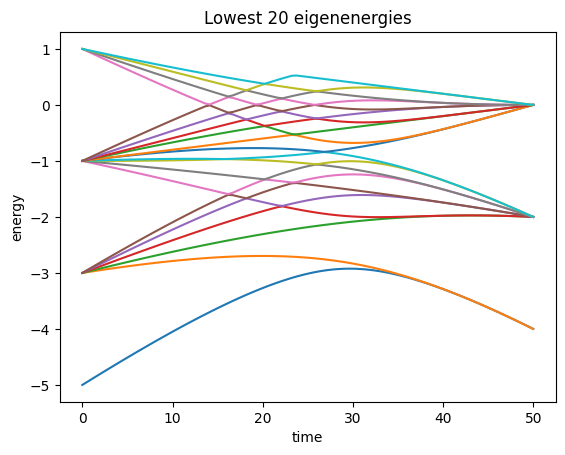

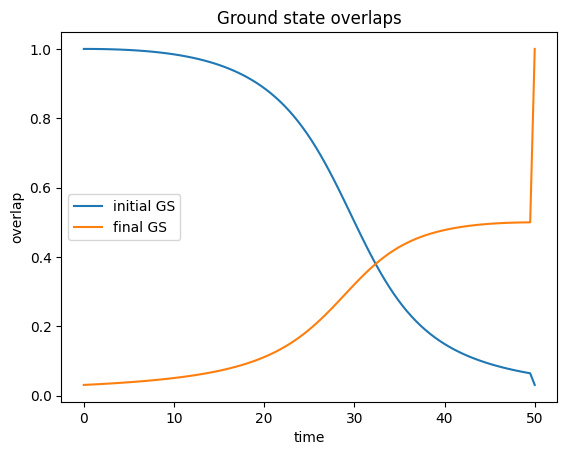

Time evolution completed. Number of states: 100


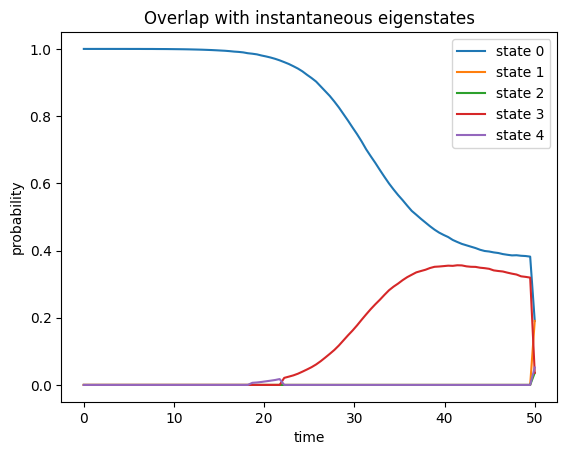

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

N = 5
t_final = 50
n_points = 100
times = np.linspace(0, t_final, n_points)

#def function

def build_operators(N):
    """Construct σx and σz tensor operators for N qubits."""
    sx_list = []
    sz_list = []
    for i in range(N):
        op_list = [qeye(2)] * N
        op_list[i] = sigmax()
        sx_list.append(tensor(op_list))
        op_list = [qeye(2)] * N
        op_list[i] = sigmaz()
        sz_list.append(tensor(op_list))
    return sx_list, sz_list

def build_hamiltonians(N):
    """Build H0 (transverse field) and H1 (Ising) Hamiltonians."""
    sx_list, sz_list = build_operators(N)
    H0 = sum(-sx for sx in sx_list)
    H1 = sum(-sz_list[i]*sz_list[i+1] for i in range(N-1))
    return H0, H1

def instantaneous_spectrum(H0, H1, times, t_final):
    """Compute eigenvalues and eigenstates of H(t) = (1-λ) H0 + λ H1."""
    eigenvals = []
    eigenstates = []
    for t in times:
        lam = t / t_final
        Ht = (1-lam)*H0 + lam*H1
        evals, evecs = Ht.eigenstates()
        eigenvals.append(evals)
        eigenstates.append(evecs)
    return np.array(eigenvals), eigenstates

def plot_eigenenergies(eigenvals, times):
    """Plot the lowest 20 eigenenergies vs time."""
    plt.figure()
    for i in range(min(20, eigenvals.shape[1])):
        plt.plot(times, eigenvals[:, i])
    plt.xlabel("time")
    plt.ylabel("energy")
    plt.title("Lowest 20 eigenenergies")
    plt.show()

def groundstate_overlap(H0, H1, eigenstates, times):
    """Compute and plot overlap of instantaneous GS with initial and final GS."""
    g0 = H0.groundstate()[1]
    g1 = H1.groundstate()[1]
    overlap_init = []
    overlap_final = []
    for i in range(len(times)):
        gs = eigenstates[i][0]
        overlap_init.append(abs(expect(g0.proj(), gs)))
        overlap_final.append(abs(expect(g1.proj(), gs)))
    plt.figure()
    plt.plot(times, overlap_init, label="initial GS")
    plt.plot(times, overlap_final, label="final GS")
    plt.xlabel("time")
    plt.ylabel("overlap")
    plt.title("Ground state overlaps")
    plt.legend()
    plt.show()

def lam(t, args):
    """Time-dependent interpolation parameter λ(t)."""
    return t / args['t_final']

def simulate_dynamics(H0, H1, times, t_final):
    """Time evolution under H(t) using mesolve."""
    psi0 = H0.groundstate()[1]
    H = [H0, [H1, lam]]
    args = {'t_final': t_final}
    result = mesolve(H, psi0, times, c_ops=[], e_ops=[], args=args) 
    return result.states

def overlaps_with_eigenstates(states, eigenstates, times):
    """Compute overlap probabilities between evolved states and instantaneous eigenstates."""
    overlaps = np.zeros((len(times), 20))
    for i, psi in enumerate(states):
        evecs = eigenstates[i]
        for j in range(min(20, len(evecs))):
            overlaps[i, j] = abs(expect(evecs[j].proj(), psi))
    plt.figure()
    for j in range(min(5, overlaps.shape[1])):
        plt.plot(times, overlaps[:, j], label=f"state {j}")
    plt.xlabel("time")
    plt.ylabel("probability")
    plt.title("Overlap with instantaneous eigenstates")
    plt.legend()
    plt.show()

#Results

print("Running basic test for the simulation...\n")

H0, H1 = build_hamiltonians(N)
print("Hamiltonians built.")

# Eigenvalues & spectrum
eigenvals, eigenstates = instantaneous_spectrum(H0, H1, times, t_final)
print("Spectrum calculated. Shape:", eigenvals.shape)

# Plot eigenenergies
plot_eigenenergies(eigenvals, times)

# Ground state overlaps
groundstate_overlap(H0, H1, eigenstates, times)

# Time evolution
states = simulate_dynamics(H0, H1, times, t_final)
print("Time evolution completed. Number of states:", len(states))

# Overlaps with instantaneous eigenstates
overlaps_with_eigenstates(states, eigenstates, times)

## Exercise 3: Adiabatic Schedules (λ(t)) for State Preparation

This code demonstrates adiabatic interpolation between a simple Hamiltonian H0 (transverse field) and a target Hamiltonian H1 (Ising chain) using different λ(t) schedules (Linear, Power-law, Optimized) to control evolution speed; it uses QuTiP to simulate the time-dependent spin chain. **Questions:** What is λ(t) used for in adiabatic evolution? How do different schedules affect the system? What happens to overlaps with H0 and H1 ground states over time? How does the number of qubits N influence the minimum gap? Which schedule spends more time near the critical region? Examine and interpret the first few λ(t) values for each schedule. 

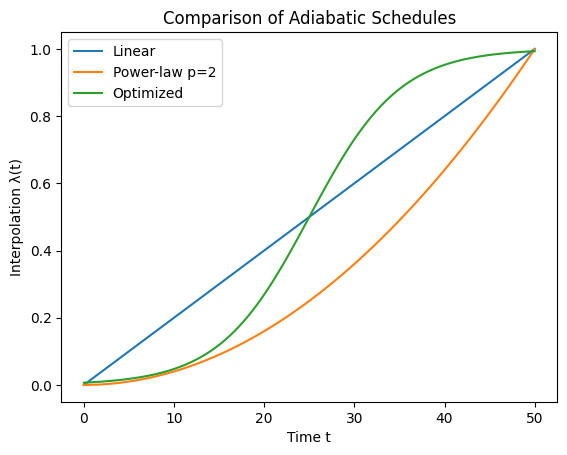

First 10 λ(t) values for each schedule:
Linear:      
 [0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909]
Power-law:   
 [0.         0.00010203 0.00040812 0.00091827 0.00163249 0.00255076
 0.00367309 0.00499949 0.00652995 0.00826446]
Optimized:   
 [0.00669285 0.00739896 0.00817894 0.00904041 0.00999169 0.01104196
 0.01220126 0.01348063 0.01489212 0.01644893]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ---------------- SCHEDULE FUNCTIONS ----------------
def linear_schedule(t, T):
    """Linear ramp: λ(t) = t/T, evolves uniformly from H0 → H1."""
    return t / T

def power_law_schedule(t, T, p=2):
    """Power-law ramp: λ(t) = (t/T)^p, slows start/end depending on p."""
    return (t / T)**p

def optimized_step_schedule(t, T, min_gap_t):
    """S-curve ramp: slows near min energy gap at t=min_gap_t using tanh."""
    normalized_t = t / T
    return 0.5 * (1 + np.tanh(5 * (normalized_t - (min_gap_t / T))))

# ---------------- SYSTEM PARAMETERS ----------------
N = 5
T = 50
n_points = 100
times = np.linspace(0, T, n_points)

# Pauli operators
sx_list = [tensor([sigmax() if i==j else qeye(2) for j in range(N)]) for i in range(N)]
sz_list = [tensor([sigmaz() if i==j else qeye(2) for j in range(N)]) for i in range(N)]

# Hamiltonians
H0 = -sum(sx_list)             # Transverse field
H1 = -sum(sz_list[i]*sz_list[i+1] for i in range(N-1))  # Ising interaction

# Initial state
psi0 = H0.groundstate()[1]

# Example minimum gap time for optimized schedule
min_gap_t = T/2

# ---------------- FUNCTION TO RUN SIMULATION ----------------
def run_simulation(schedule_func, schedule_name):
    """Simulate evolution using given schedule function."""
    H_td = [H0, [H1, lambda t, args: schedule_func(t, args['T'])]] if schedule_name != "Optimized" else \
           [H0, [H1, lambda t, args: schedule_func(t, args['T'], min_gap_t)]]
    
    result = mesolve(H_td, psi0, times, c_ops=[], e_ops=[], args={'T': T})
    # Plot interpolation λ(t)
    lam_vals = np.array([schedule_func(t, T) if schedule_name != "Optimized" else schedule_func(t, T, min_gap_t) for t in times])
    plt.plot(times, lam_vals, label=schedule_name)

# ---------------- RUN AND PLOT ALL THREE SCHEDULES ----------------
plt.figure()
run_simulation(linear_schedule, "Linear")
run_simulation(power_law_schedule, "Power-law p=2")
run_simulation(optimized_step_schedule, "Optimized")
plt.xlabel("Time t")
plt.ylabel("Interpolation λ(t)")
plt.title("Comparison of Adiabatic Schedules")
plt.legend()
plt.show()
# ---------------- PRINT FIRST FEW VALUES ----------------
print("First 10 λ(t) values for each schedule:")
print("Linear:      \n", lambda_linear[:10])
print("Power-law:   \n", lambda_power[:10])
print("Optimized:   \n", lambda_optimized[:10])

# Adiabatic State Preparation (ASP) – Summary

**Goal:** Prepare the ground state of a complex Hamiltonian \(H_1\) by slowly evolving from a simple Hamiltonian \(H_0\).



## 1. Hamiltonians
- **H0:** Simple, easy-to-prepare ground state (e.g., transverse field).  
- **H1:** Target Hamiltonian (e.g., Ising chain).  
- **Time-dependent:**  
\[
H(t) = (1 - \lambda(t)) H_0 + \lambda(t) H_1, \quad \lambda(0)=0, \lambda(T)=1
\]



## 2. Schedules (λ(t))
- **Linear:** \(\lambda(t)=t/T\) (uniform evolution)  
- **Power-law:** \(\lambda(t)=(t/T)^p\) (slower start/end)  
- **Optimized/S-curve:** slows near **minimum gap** to reduce excitations  



## 3. Key Concepts
- **Instantaneous eigenstates:** \(H(t)|\psi_n(t)\rangle = E_n(t)|\psi_n(t)\rangle\)  
- **Excitation gap:** \(E_1(t)-E_0(t)\), evolution must be slowest here  
- **Adiabatic theorem:** Slow evolution keeps system in ground state  



## 4. Observables
- **Eigenenergies vs time:** shows avoided crossings  
- **Ground state overlap:** instantaneous vs initial/final GS  
- **Population dynamics:** overlap of \(|\psi(t)\rangle\) with instantaneous eigenstates  



## 5. Practical Steps (QuTiP)
1. Build tensor-product Pauli operators for N qubits.  
2. Construct H0 (transverse) and H1 (Ising).  
3. Define λ(t) schedule.  
4. Solve Schrödinger equation with `mesolve()`.  
5. Plot λ(t), eigenenergies, overlaps to monitor evolution.



**Key Insight:** Slow down near minimum gap; choice of schedule affects speed and fidelity.  